## **1. Overview and Theoretical Framework**

### **1.1 Introduction to the PyTorch Workflow**

This comprehensive tutorial covers the standard PyTorch workflow for developing machine learning models. **The workflow represents a systematic approach to solving machine learning problems**, from data preparation through model deployment. While this framework can be adapted based on specific requirements, it encompasses the fundamental steps necessary for most deep learning applications.

### **1.2 Pedagogical Approach**

The workflow presented here follows established best practices in machine learning engineering and research. Each component of the workflow addresses specific challenges in the model development lifecycle, ensuring reproducibility, maintainability, and scientific rigor.

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01_a_pytorch_workflow.png" width=900 alt="PyTorch workflow flowchart showing the complete machine learning pipeline"/>



### **1.3 Workflow Components and Learning Outcomes**

This tutorial demonstrates the workflow using a **linear regression case study** to predict patterns in synthetic data. The methodological approach presented here is generalizable to complex deep learning problems involving real-world datasets.

The workflow encompasses the following key components:

| **Module** | **Learning Outcomes** | **Practical Applications** |
|------------|----------------------|---------------------------|
| **1. Data Preparation and Loading** | Master data creation, preprocessing, and efficient loading using DataLoader | Foundation for handling real-world datasets, implementing batching strategies |
| **2. Model Architecture Design** | Understand model construction, loss functions, and optimization strategies | Building neural networks with appropriate architectures for specific problems |
| **3. Training and Optimization** | Implement training loops with proper gradient computation and parameter updates | Developing robust training procedures for deep learning models |
| **4. Model Evaluation and Inference** | Apply proper evaluation methodologies and make predictions on unseen data | Assessing model performance and deploying models for practical applications |
| **5. Model Persistence and Management** | Manage model saving, loading, and versioning for reproducible research | Ensuring reproducibility and facilitating model deployment |
| **6. Advanced Techniques** | Implement custom loss functions and data loading strategies | Addressing specialized requirements in research and industry applications |

### **1.4 Mathematical Framework**

Throughout this tutorial, we implement the fundamental equation for linear regression:

**ŷ = Wx + b**

Where:
- **ŷ**: Predicted output
- **W**: Weight parameter (slope)
- **x**: Input feature
- **b**: Bias parameter (intercept)

This simple relationship serves as the foundation for understanding more complex neural network architectures.

## **2. Data Preparation and Preprocessing**

### **2.1 Generating Synthetic Data (The Ground Truth)**
As discussed in the lecture, to understand the training pipeline under perfect laboratory conditions, we begin by generating data with known parameters.

**The Ground Truth Equation:** $y = weight \cdot X + bias$
*   **Weight:** 0.7
*   **Bias:** 0.3

Our goal is to start with random numbers and see if PyTorch can find these exact values.

### **2.1 Theoretical Foundation**

![Machine learning conceptual framework showing the two-part process of data representation and model learning](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-machine-learning-a-game-of-two-parts.png)



**Machine learning fundamentally operates on two core principles:**

1. **Data Representation**: Transform raw data into numerical representations suitable for mathematical operations
2. **Pattern Learning**: Develop mathematical models that can learn optimal representations to minimize prediction errors

This framework applies universally across all machine learning domains, from computer vision to natural language processing.

### **2.2 Experimental Design: Synthetic Data Generation**

**To understand the training pipeline under perfect laboratory conditions, we begin by generating synthetic linear data with known underlying parameters (ground truth weights and biases).**

#### **2.2.1 The Ground Truth Equation**
Our model follows the relationship:
**$y = weight \cdot X + bias$**

*   **True Parameters:** The weight (slope) is explicitly set to **0.7**, and the bias (intercept) is set to **0.3**.
*   **The Objective:** Our future model will start with completely random numbers. The goal is for the model to find these exact values through training.

In [2]:
# Import essential libraries for deep learning and visualization
import torch
from torch import nn  # Contains all PyTorch building blocks for neural networks
import matplotlib.pyplot as plt

# Verify PyTorch installation and version compatibility
# This ensures reproducibility across different environments
print(f"PyTorch Version: {torch.__version__}")

# Display system information for debugging purposes
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.11.0+cpu
CUDA Available: False


In [3]:
import torch

# 1. Define Ground Truth Parameters
weight = 0.7
bias = 0.3

# 2. Creating the Input Vector (X)
# We use torch.arange to create 50 evenly distributed points between 0 and 1
start = 0
end = 1
step = 0.02
X_raw = torch.arange(start, end, step)

# 3. The Feature Dimension Requirement (.unsqueeze)
# Modern deep learning layers require a 2D shape: [batch_size, num_features].
# A raw 1D tensor [50] will break matrix multiplications inside model layers.
# .unsqueeze(dim=1) morphs the shape from [50] to [50, 1].
X = X_raw.unsqueeze(dim=1)

# 4. Generate Target Labels (y)
y = weight * X + bias

print(f"X shape: {X.shape} (Structured 2D feature matrix)")
print(f"First 5 X values:\n{X[:5]}")
print(f"First 5 y values:\n{y[:5]}")

X shape: torch.Size([50, 1]) (Structured 2D feature matrix)
First 5 X values:
tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800]])
First 5 y values:
tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560]])


### **2.3 Dataset Partitioning: Training and Testing Split**

**Data partitioning represents a fundamental requirement in machine learning to ensure unbiased model evaluation.** The separation of data into distinct subsets serves different purposes in the model development lifecycle.

#### **2.3.1 Theoretical Justification**

Data splitting addresses the **bias-variance tradeoff** and prevents **overfitting** by:

1. **Training Set**: Enables parameter optimization through gradient descent
2. **Validation Set**: Facilitates hyperparameter tuning and model selection
3. **Test Set**: Provides unbiased performance estimation on unseen data

#### **2.3.2 Standard Partitioning Protocols**

| **Subset** | **Purpose** | **Typical Allocation** | **Usage Frequency** |
|------------|-------------|----------------------|-------------------|
| **Training Set** | Parameter optimization and pattern learning | 60-80% | Every training iteration |
| **Validation Set** | Hyperparameter tuning and model selection | 10-20% | During development phase |
| **Test Set** | Final performance evaluation and generalization assessment | 10-20% | Once at project completion |

#### **2.3.3 Methodological Considerations**

**Important:** In production machine learning systems, the test set should remain completely isolated during the entire development process. This ensures that performance metrics provide genuine estimates of model generalization capability.

#### **2.3.4 Best Practices in Data Management**

> **Research Protocol:** In real-world applications, data partitioning should occur immediately after data collection and preprocessing. The test set must remain isolated throughout the entire model development lifecycle to maintain scientific integrity and ensure valid generalization estimates. This principle, known as **data leakage prevention**, is essential for reproducible research and reliable model deployment.

In [4]:
# Implement 80-20 train-test split following standard ML protocols
# This ratio provides sufficient training data while reserving adequate samples for evaluation
train_split = int(0.8 * len(X))  # 80% allocation for training

# Partition the dataset using temporal ordering (first 80% for training)
# Note: In practice, random shuffling is often preferred to avoid temporal bias
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

# Verify partitioning results
print(f"Dataset Partitioning Summary:")
print(f"Training Set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test Set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Total Samples: {len(X_train) + len(X_test)}")

# Verify data integrity
assert len(X_train) + len(X_test) == len(X), "Data partitioning error detected"

Dataset Partitioning Summary:
Training Set: 40 samples (80.0%)
Test Set: 10 samples (20.0%)
Total Samples: 50


### **2.4 Efficient Data Loading (TensorDataset & DataLoader)**

#### **2.4.1 Packaging with TensorDataset**
`torch.utils.data.TensorDataset(X, y)` wraps your features and labels into a single entity. It aligns them sample-by-sample so indexing `dataset[i]` always returns the correct pair.

#### **2.4.2 The DataLoader Pipeline**
You cannot load millions of data points into RAM at once. We use the `DataLoader` as a **generator pipeline**:
*   **Batching**: Slices 50 samples into micro-groups (e.g., batch_size=8).
*   **Shuffling**: Randomizes the order every epoch to prevent the model from simply memorizing sequence patterns.
*   **Parallel Processing**: Uses `num_workers` to pre-fetch data, preventing bottlenecks.

In [5]:
# Import necessary components for data loading
from torch.utils.data import TensorDataset, DataLoader

# Create TensorDataset objects for efficient data handling
# TensorDataset wraps tensors to provide indexing and length operations
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Configure DataLoader parameters for training and testing
BATCH_SIZE = 8  # Small batch size for demonstration (typically 32, 64, 128, or 256)
NUM_WORKERS = 0  # Number of subprocesses for data loading (set to 0 for single-threaded)

# Create DataLoader instances
# Training DataLoader with shuffling to prevent order bias
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,  # Randomize sample order for each epoch
    num_workers=NUM_WORKERS
)

# Test DataLoader without shuffling to maintain reproducible evaluation
test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,  # Preserve original order for consistent evaluation
    num_workers=NUM_WORKERS
)

# Display DataLoader properties
print(f"DataLoader Configuration:")
print(f"Training Batches: {len(train_dataloader)}")
print(f"Test Batches: {len(test_dataloader)}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Total Training Samples: {len(train_dataset)}")
print(f"Total Test Samples: {len(test_dataset)}")

# Demonstrate batch iteration
print(f"\nFirst Training Batch:")
for batch_X, batch_y in train_dataloader:
    print(f"Batch X shape: {batch_X.shape}")
    print(f"Batch y shape: {batch_y.shape}")
    print(f"Batch X: {batch_X.flatten()}")
    print(f"Batch y: {batch_y.flatten()}")
    break  # Only show first batch

DataLoader Configuration:
Training Batches: 5
Test Batches: 2
Batch Size: 8
Total Training Samples: 40
Total Test Samples: 10

First Training Batch:
Batch X shape: torch.Size([8, 1])
Batch y shape: torch.Size([8, 1])
Batch X: tensor([0.5200, 0.4000, 0.0400, 0.0800, 0.0200, 0.2400, 0.4800, 0.3600])
Batch y: tensor([0.6640, 0.5800, 0.3280, 0.3560, 0.3140, 0.4680, 0.6360, 0.5520])


In [6]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Visualize training data, test data, and model predictions for regression analysis.

    This function creates a comprehensive visualization that enables:
    1. Assessment of data distribution and quality
    2. Evaluation of model prediction accuracy
    3. Identification of potential overfitting or underfitting patterns

    Parameters:
    -----------
    train_data : torch.Tensor
        Training feature values for visualization
    train_labels : torch.Tensor
        Training target values for visualization
    test_data : torch.Tensor
        Test feature values for visualization
    test_labels : torch.Tensor
        Test target values for visualization
    predictions : torch.Tensor, optional
        Model predictions on test data for comparison

    Returns:
    --------
    None
        Displays matplotlib figure with data visualization
    """
    # Configure figure with professional formatting
    plt.figure(figsize=(12, 8))

    # Plot training data with distinct visual encoding
    plt.scatter(train_data, train_labels,
               c="blue", s=25, alpha=0.7,
               label="Training Data", marker='o')

    # Plot test data with distinct visual encoding
    plt.scatter(test_data, test_labels,
               c="green", s=25, alpha=0.7,
               label="Test Data", marker='s')

    # Plot predictions if provided
    if predictions is not None:
        plt.scatter(test_data, predictions,
                   c="red", s=25, alpha=0.8,
                   label="Model Predictions", marker='^')

    # Configure professional plot formatting
    plt.xlabel("Input Features (x)", fontsize=12)
    plt.ylabel("Target Values (y)", fontsize=12)
    plt.title("Linear Regression: Data Distribution and Model Predictions",
              fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Display the plot
    plt.show()

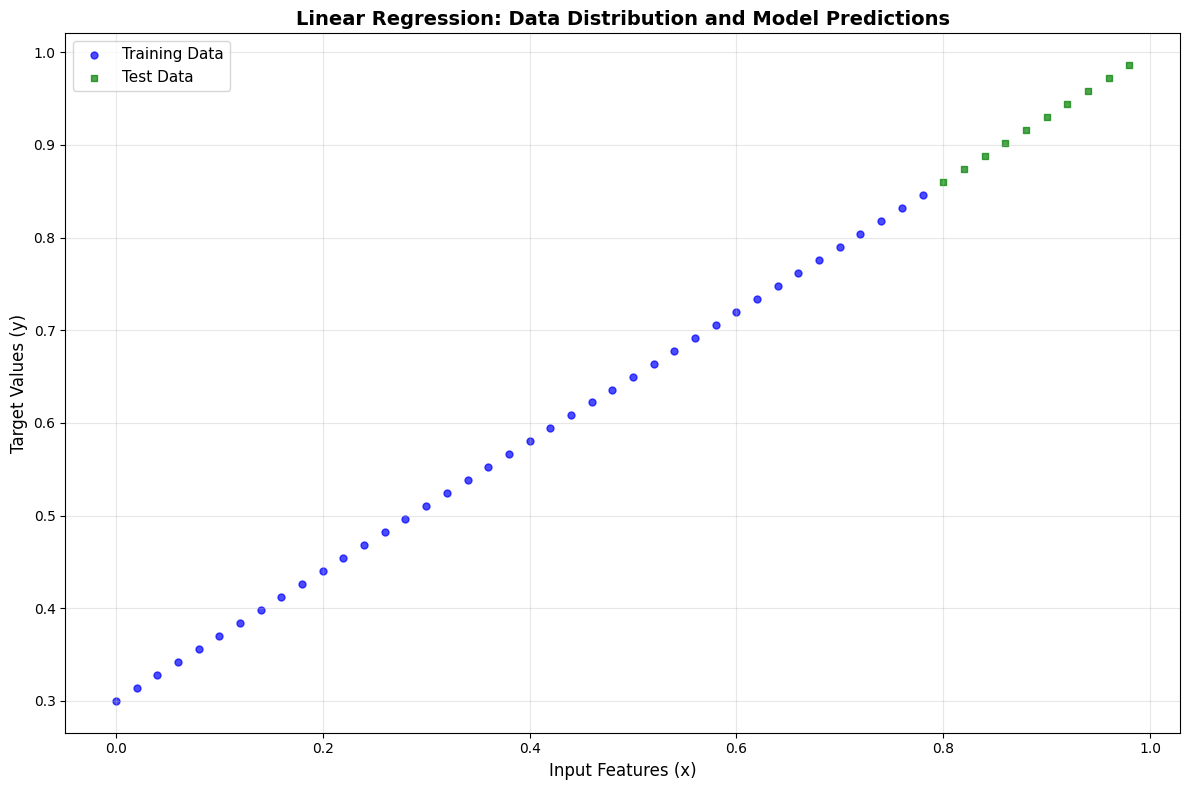

In [ ]:
plot_predictions();

## **3. Model Architecture and Design**

### **3.1 Building Models with nn.Module (Neural Network Lego Blocks)**

Almost everything in PyTorch is a `nn.Module`. Think of these as building blocks. To create a model, we subclass `nn.Module` and must implement two main parts:
1.  **`__init__`**: Where we define our parameters (weights/biases).
2.  **`forward()`**: Where we define the computation (the formula).

In [8]:
# Define Linear Regression Model Architecture
# This implementation demonstrates fundamental PyTorch model construction principles

class LinearRegressionModel(nn.Module):
    """
    Linear Regression Model Implementation using PyTorch.

    This model implements the mathematical relationship: y = Wx + b
    where W and b are learnable parameters optimized through gradient descent.

    Architecture Details:
    - Input Dimension: 1 (single feature)
    - Output Dimension: 1 (single prediction)
    - Parameters: 2 (weight and bias)
    - Activation Function: None (linear transformation)
    """

    def __init__(self):
        """
        Initialize model parameters with random values.

        The super().__init__() call enables PyTorch's automatic differentiation
        and parameter management functionality.
        """
        super().__init__()

        # Initialize weight parameter with random normal distribution
        # requires_grad=True enables automatic gradient computation
        self.weights = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

        # Initialize bias parameter with random normal distribution
        self.bias = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Define forward pass computation.

        Parameters:
        -----------
        x : torch.Tensor
            Input features with shape [batch_size, input_dim]

        Returns:
        --------
        torch.Tensor
            Predictions with shape [batch_size, output_dim]
        """
        # Implement linear transformation: y = Wx + b
        return self.weights * x + self.bias

Alright there's a fair bit going on above but let's break it down bit by bit.

```python
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)
```

### **3.2 PyTorch model building essentials**

PyTorch has four (give or take) essential modules you can use to create almost any kind of neural network you can imagine.


They are [`torch.nn`](https://pytorch.org/docs/stable/nn.html), [`torch.optim`](https://pytorch.org/docs/stable/optim.html), [`torch.utils.data.Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) and [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html). For now, we'll focus on the first two and get to the other two later (though you may be able to guess what they do).

| PyTorch module | What does it do? |
| ----- | ----- |
| [`torch.nn`](https://pytorch.org/docs/stable/nn.html) | Contains all of the building blocks for computational graphs (essentially a series of computations executed in a particular way). |
| [`torch.nn.Parameter`](https://pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html#parameter) | Stores tensors that can be used with `nn.Module`. If `requires_grad=True` gradients (used for updating model parameters via [**gradient descent**](https://ml-cheatsheet.readthedocs.io/en/latest/gradient_descent.html))  are calculated automatically, this is often referred to as "autograd".  |
| [`torch.nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module) | The base class for all neural network modules, all the building blocks for neural networks are subclasses. If you're building a neural network in PyTorch, your models should subclass `nn.Module`. Requires a `forward()` method be implemented. |
| [`torch.optim`](https://pytorch.org/docs/stable/optim.html) | Contains various optimization algorithms (these tell the model parameters stored in `nn.Parameter` how to best change to improve gradient descent and in turn reduce the loss). |
| `def forward()` | All `nn.Module` subclasses require a `forward()` method, this defines the computation that will take place on the data passed to the particular `nn.Module` (e.g. the linear regression formula above). |

If the above sounds complex, think of like this, almost everything in a PyTorch neural network comes from `torch.nn`,
* `nn.Module` contains the larger building blocks (layers)
* `nn.Parameter` contains the smaller parameters like weights and biases (put these together to make `nn.Module`(s))
* `forward()` tells the larger blocks how to make calculations on inputs (tensors full of data) within  `nn.Module`(s)
* `torch.optim` contains optimization methods on how to improve the parameters within `nn.Parameter` to better represent input data

![a pytorch linear model with annotations](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-linear-model-annotated.png)

Source: learnpytorch.io



### **3.3 Loss Functions: Measuring 'Wrongness'**

**Loss functions quantify the discrepancy between predictions and ground truth.**
- **MAE (L1 Loss)**: Mean Absolute Error. It's robust and calculates the average of absolute differences.
- **Custom Loss**: We can build our own by subclassing `nn.Module` to incorporate domain-specific constraints.

In [9]:
# Custom Loss Function Implementations

class MeanAbsoluteError(nn.Module):
    """
    Custom implementation of Mean Absolute Error (L1 Loss).

    Mathematical Definition:
    MAE = (1/n) * Σ|y_true - y_pred|

    This implementation demonstrates the structure for creating custom loss functions
    while replicating the functionality of PyTorch's built-in nn.L1Loss().
    """

    def __init__(self):
        super().__init__()

    def forward(self, predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Compute Mean Absolute Error between predictions and targets.

        Parameters:
        -----------
        predictions : torch.Tensor
            Model predictions with shape [batch_size, output_dim]
        targets : torch.Tensor
            Ground truth values with shape [batch_size, output_dim]

        Returns:
        --------
        torch.Tensor
            Scalar loss value
        """
        # Compute absolute differences
        absolute_errors = torch.abs(predictions - targets)

        # Return mean across all elements
        return torch.mean(absolute_errors)


class HuberLoss(nn.Module):
    """
    Custom Huber Loss implementation.

    Huber loss combines the advantages of MSE and MAE:
    - Quadratic for small errors (smooth gradients)
    - Linear for large errors (robust to outliers)

    Mathematical Definition:
    L_δ(a) = { 0.5 * a²      if |a| ≤ δ
             { δ * |a| - 0.5 * δ²  if |a| > δ

    where a = y_true - y_pred and δ is the threshold parameter.
    """

    def __init__(self, delta: float = 1.0):
        """
        Initialize Huber loss with specified threshold.

        Parameters:
        -----------
        delta : float
            Threshold parameter controlling transition between quadratic and linear regions
        """
        super().__init__()
        self.delta = delta

    def forward(self, predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Compute Huber loss between predictions and targets.

        Parameters:
        -----------
        predictions : torch.Tensor
            Model predictions
        targets : torch.Tensor
            Ground truth values

        Returns:
        --------
        torch.Tensor
            Scalar loss value
        """
        # Compute residuals
        residuals = predictions - targets
        abs_residuals = torch.abs(residuals)

        # Apply Huber loss formulation
        quadratic_mask = abs_residuals <= self.delta
        linear_mask = abs_residuals > self.delta

        # Quadratic component: 0.5 * residual²
        quadratic_loss = 0.5 * residuals ** 2

        # Linear component: δ * |residual| - 0.5 * δ²
        linear_loss = self.delta * abs_residuals - 0.5 * self.delta ** 2

        # Combine components based on masks
        loss = quadratic_mask * quadratic_loss + linear_mask * linear_loss

        return torch.mean(loss)


# Demonstrate custom loss function instantiation
custom_mae_loss = MeanAbsoluteError()
huber_loss = HuberLoss(delta=1.0)

print("Custom Loss Functions Initialized:")
print(f"Custom MAE Loss: {custom_mae_loss}")
print(f"Huber Loss (δ=1.0): {huber_loss}")

# Test custom loss functions with sample data
sample_predictions = torch.tensor([1.0, 2.0, 3.0])
sample_targets = torch.tensor([1.1, 1.8, 3.2])

print(f"\nLoss Function Comparison (Sample Data):")
print(f"Built-in L1Loss: {nn.L1Loss()(sample_predictions, sample_targets):.4f}")
print(f"Custom MAE Loss: {custom_mae_loss(sample_predictions, sample_targets):.4f}")
print(f"Huber Loss: {huber_loss(sample_predictions, sample_targets):.4f}")

Custom Loss Functions Initialized:
Custom MAE Loss: MeanAbsoluteError()
Huber Loss (δ=1.0): HuberLoss()

Loss Function Comparison (Sample Data):
Built-in L1Loss: 0.1667
Custom MAE Loss: 0.1667
Huber Loss: 0.0150


### **3.4 Checking the contents of a PyTorch model**

In [10]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [11]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### **3.5 Making predictions**

When we pass data to our model, it'll go through the model's `forward()` method and produce a result using the computation we've defined.

Let's make some predictions.

In [12]:
# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

In [13]:

# Note: in older PyTorch code you might also see torch.no_grad()
with torch.no_grad():
  y_preds = model_0(X_test)

In [14]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


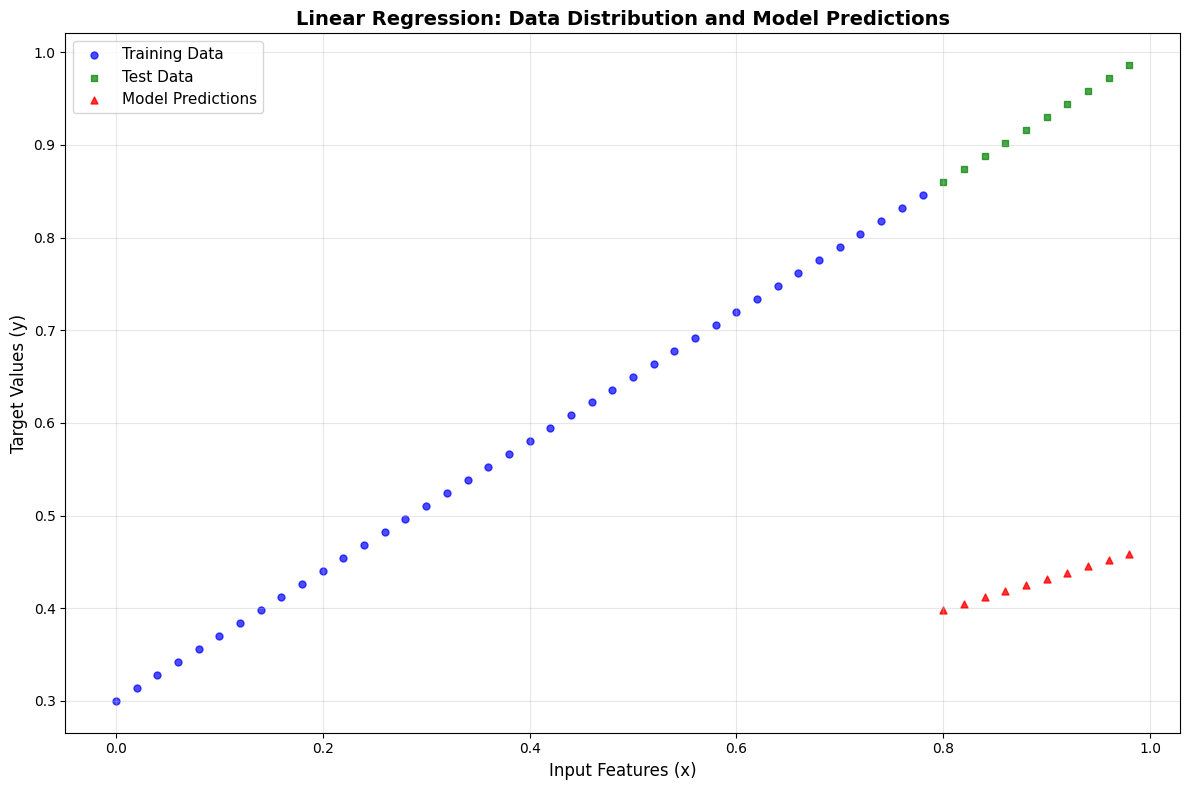

In [15]:
plot_predictions(predictions=y_preds)

In [16]:
y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

## **4. Model Training and Optimization**

### **4.1 Theoretical Framework for Neural Network Training**

**The training process requires two fundamental components: a loss function to quantify prediction errors and an optimization algorithm to update model parameters.** These components work synergistically to enable automatic parameter learning through gradient-based optimization.

#### **4.1.1 Mathematical Framework**

The optimization process follows the iterative update rule:

**θₜ₊₁ = θₜ - η∇θL(θₜ)**

Where:
- **θₜ**: Parameters at iteration t
- **η**: Learning rate (step size)
- **∇θL(θₜ)**: Gradient of loss function with respect to parameters
- **L(θₜ)**: Loss function value at current parameters

#### **4.1.2 Component Selection Guidelines**

| **Component** | **Purpose** | **PyTorch Location** | **Common Choices** |
|---------------|-------------|---------------------|-------------------|
| **Loss Function** | Quantifies prediction accuracy and provides optimization signal | [`torch.nn`](https://pytorch.org/docs/stable/nn.html#loss-functions) | MAE (`nn.L1Loss`) for regression, Cross-entropy (`nn.CrossEntropyLoss`) for classification |
| **Optimizer** | Implements parameter update rules using gradient information | [`torch.optim`](https://pytorch.org/docs/stable/optim.html) | SGD (`torch.optim.SGD`) for stability, Adam (`torch.optim.Adam`) for adaptive learning |

In [17]:
# Configure loss function for regression task
# Mean Absolute Error (L1 Loss) provides robust optimization for linear regression
loss_fn = nn.L1Loss()

# Alternative: Use custom loss function for demonstration
# loss_fn = custom_mae_loss  # Equivalent to nn.L1Loss()
# loss_fn = huber_loss       # Robust to outliers

# Configure optimization algorithm
# Stochastic Gradient Descent (SGD) with appropriate learning rate
optimizer = torch.optim.SGD(
    params=model_0.parameters(),  # Target model parameters for optimization
    lr=0.001                       # Learning rate (α): controls step size in parameter space
)

print(f"Training Configuration:")
print(f"Loss Function: {loss_fn}")
print(f"Optimizer: {optimizer}")
print(f"Learning Rate: {optimizer.param_groups[0]['lr']}")
print(f"Parameters to Optimize: {len(list(model_0.parameters()))}")

Training Configuration:
Loss Function: L1Loss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
Learning Rate: 0.001
Parameters to Optimize: 2


### **4.1.3 Understanding Epochs**

As discussed in the lecture, an **Epoch** represents one full cycle through the entire training dataset.

*   **Why do we need multiple epochs?** During a single epoch, the model may only see each pattern once. By repeating the process (e.g., `EPOCHS = 100`), the optimizer has more opportunities to adjust the weights and biases to reduce the loss.
*   **The Trade-off:** Too few epochs lead to **underfitting** (the model hasn't learned enough), while too many can lead to **overfitting** (the model memorizes the specific noise in the training data).

### **4.2 The 5-Step Training Loop**

The training process is a systematic cycle. For every epoch, we perform these 5 steps:

1.  **Forward Pass**: `model(X_train)` - Calculate predictions.
2.  **Calculate Loss**: `loss_fn(y_pred, y_train)` - See how 'wrong' the model is.
3.  **Zero Gradients**: `optimizer.zero_grad()` - Clear the memory from the last step.
4.  **Backpropagation**: `loss.backward()` - Calculate the gradient (direction) for every parameter.
5.  **Optimizer Step**: `optimizer.step()` - Move the parameters slightly to reduce the loss.

#### **4.2.2 Training Loop: Systematic Parameter Optimization**

**The training loop implements the core gradient descent algorithm through five essential steps executed iteratively.** Each step serves a specific mathematical purpose in the optimization process.

#### **4.2.3 Training Phase Steps**

| **Step** | **Operation** | **Mathematical Purpose** | **PyTorch Implementation** |
|----------|---------------|-------------------------|---------------------------|
| 1 | **Forward Pass** | Compute predictions using current parameters | `y_pred = model(X_train)` |
| 2 | **Loss Calculation** | Quantify prediction error against ground truth | `loss = loss_fn(y_pred, y_train)` |
| 3 | **Gradient Zeroing** | Reset accumulated gradients from previous iterations | `optimizer.zero_grad()` |
| 4 | **Backpropagation** | Compute gradients via automatic differentiation | `loss.backward()` |
| 5 | **Parameter Update** | Apply gradient descent update rule | `optimizer.step()` |

#### **4.2.4 Mathematical Interpretation**

Each step corresponds to a specific component of the gradient descent algorithm:

- **Steps 1-2**: Implement the loss function **L(θ) = f(h_θ(X), y)**
- **Step 3**: Ensures clean gradient computation for current iteration
- **Step 4**: Computes **∇_θ L(θ)** using chain rule via backpropagation
- **Step 5**: Updates parameters using **θ := θ - η∇_θ L(θ)**

#### **4.2.5 Training in Pytorch**

![PyTorch optimization loop conceptual diagram](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-optimization-loop-song.png)

*Source: learnpytorch.io*

```python
# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100
for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()
```

![pytorch training loop annotated](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-training-loop-annotated.png)

Source: learnpytorch.io

### **4.3 Testing loop Implementation**

As for the testing loop (evaluating our model), the typical steps include:

| Number | Step name | What does it do? | Code example |
| ----- | ----- | ----- | ----- |
| 1 | Forward pass | The model goes through all of the testing data once, performing its `forward()` function calculations. | `model(x_test)` |
| 2 | Calculate the loss | The model's outputs (predictions) are compared to the ground truth and evaluated to see how wrong they are. | `loss = loss_fn(y_pred, y_test)` |
| 3 | Calulate evaluation metrics (optional) | Alongside the loss value you may want to calculate other evaluation metrics such as accuracy on the test set. | Custom functions |


Notice the testing loop doesn't contain performing backpropagation (`loss.backward()`) or stepping the optimizer (`optimizer.step()`), this is because no parameters in the model are being changed during testing, they've already been calculated. For testing, we're only interested in the output of the forward pass through the model.

```python
    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions

      # Print out what's happening
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")
```


![pytorch annotated testing loop](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-testing-loop-annotated.png)

Source: learnpytorch.io

Let's put all of the above together and train our model for 100 **epochs** (forward passes through the data) and we'll evaluate it every 10 epochs.

In [18]:
# Set random seed for reproducible results across experiments
torch.manual_seed(42)

# Configure training hyperparameters
EPOCHS = 350  # Number of complete passes through the training dataset
PRINT_INTERVAL = 20  # Frequency for progress reporting

# Initialize tracking variables for loss curves
train_loss_values = []
test_loss_values = []
epoch_count = []

print("Training Progress:")
print("=" * 60)

# Main training loop: iterate through epochs
for epoch in range(EPOCHS):

    ### TRAINING PHASE ###
    model_0.train()  # Set model to training mode (enables gradient computation)

    # Initialize epoch training loss accumulator
    epoch_train_loss = 0.0
    num_train_batches = 0

    # Iterate through training batches using DataLoader
    for batch_X, batch_y in train_dataloader:

        # Step 1: Forward pass - compute predictions for current batch
        y_pred = model_0(batch_X)

        # Step 2: Compute loss for current batch
        batch_loss = loss_fn(y_pred, batch_y)

        # Step 3: Zero gradients from previous iteration
        optimizer.zero_grad()

        # Step 4: Backward pass - compute gradients via automatic differentiation
        batch_loss.backward()

        # Step 5: Update parameters using computed gradients
        optimizer.step()

        # Accumulate batch loss for epoch average
        epoch_train_loss += batch_loss.item()
        num_train_batches += 1

    # Calculate average training loss for epoch
    avg_train_loss = epoch_train_loss / num_train_batches

    ### EVALUATION PHASE ###
    model_0.eval()  # Set model to evaluation mode (disables gradient computation)

    # Initialize epoch test loss accumulator
    epoch_test_loss = 0.0
    num_test_batches = 0

    # Evaluate on test data without gradient computation
    with torch.inference_mode():
        for batch_X, batch_y in test_dataloader:

            # Forward pass on test batch
            test_pred = model_0(batch_X)

            # Compute test loss for current batch
            batch_test_loss = loss_fn(test_pred, batch_y)

            # Accumulate batch loss for epoch average
            epoch_test_loss += batch_test_loss.item()
            num_test_batches += 1

    # Calculate average test loss for epoch
    avg_test_loss = epoch_test_loss / num_test_batches

    # Record metrics and display progress at specified intervals
    if epoch % PRINT_INTERVAL == 0:
        epoch_count.append(epoch)
        train_loss_values.append(avg_train_loss)
        test_loss_values.append(avg_test_loss)

        print(f"Epoch: {epoch:3d} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")

print("=" * 60)
print("Training completed successfully!")
print(f"Final Training Loss: {avg_train_loss:.6f}")
print(f"Final Test Loss: {avg_test_loss:.6f}")

Training Progress:
Epoch:   0 | Train Loss: 0.310581 | Test Loss: 0.498641
Epoch:  20 | Train Loss: 0.195369 | Test Loss: 0.362761
Epoch:  40 | Train Loss: 0.088470 | Test Loss: 0.232256
Epoch:  60 | Train Loss: 0.053368 | Test Loss: 0.156513
Epoch:  80 | Train Loss: 0.045415 | Test Loss: 0.122476
Epoch: 100 | Train Loss: 0.041541 | Test Loss: 0.106128
Epoch: 120 | Train Loss: 0.038049 | Test Loss: 0.094914
Epoch: 140 | Train Loss: 0.034658 | Test Loss: 0.085780
Epoch: 160 | Train Loss: 0.031305 | Test Loss: 0.077340
Epoch: 180 | Train Loss: 0.027754 | Test Loss: 0.068899
Epoch: 200 | Train Loss: 0.024343 | Test Loss: 0.060112
Epoch: 220 | Train Loss: 0.020869 | Test Loss: 0.051325
Epoch: 240 | Train Loss: 0.017441 | Test Loss: 0.043231
Epoch: 260 | Train Loss: 0.014093 | Test Loss: 0.034790
Epoch: 280 | Train Loss: 0.010688 | Test Loss: 0.026003
Epoch: 300 | Train Loss: 0.007193 | Test Loss: 0.017562
Epoch: 320 | Train Loss: 0.003743 | Test Loss: 0.009491
Epoch: 340 | Train Loss: 0.00

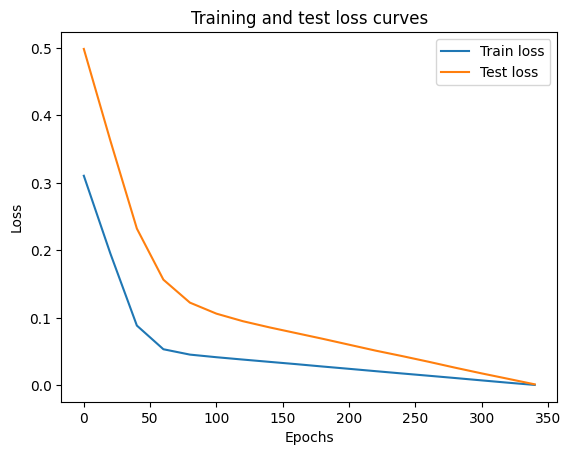

In [19]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [20]:
# Analyze learned parameters compared to ground truth values
print("Parameter Learning Analysis:")
print("=" * 50)

learned_params = model_0.state_dict()
print("Learned Parameters:")
for param_name, param_value in learned_params.items():
    print(f"  {param_name}: {param_value.item():.6f}")

print("\nGround Truth Parameters:")
print(f"  weights: {weight:.6f}")
print(f"  bias: {bias:.6f}")

print("\nParameter Recovery Analysis:")
weight_error = abs(learned_params['weights'].item() - weight)
bias_error = abs(learned_params['bias'].item() - bias)
print(f"  Weight Error: {weight_error:.6f}")
print(f"  Bias Error: {bias_error:.6f}")
print(f"  Total Absolute Error: {weight_error + bias_error:.6f}")

# Assess convergence quality
if weight_error < 0.01 and bias_error < 0.01:
    print("\n✓ Excellent parameter recovery achieved!")
elif weight_error < 0.05 and bias_error < 0.05:
    print("\n✓ Good parameter recovery achieved!")
else:
    print("\n⚠ Parameter recovery may require additional training or hyperparameter tuning.")

Parameter Learning Analysis:
Learned Parameters:
  weights: 0.700031
  bias: 0.300808

Ground Truth Parameters:
  weights: 0.700000
  bias: 0.300000

Parameter Recovery Analysis:
  Weight Error: 0.000031
  Bias Error: 0.000808
  Total Absolute Error: 0.000839

✓ Excellent parameter recovery achieved!


## **5. Model Evaluation and Inference**

### **5.1 Systematic Approach to Model Evaluation**

**Model evaluation requires adherence to specific protocols to ensure valid performance assessment.** The following three principles are essential for proper inference:

#### **5.1.1 Evaluation Protocol Requirements**

1. **Model Mode Configuration**: Set model to evaluation mode using `model.eval()`
   - Disables training-specific behaviors (dropout, batch normalization updates)
   - Ensures consistent inference behavior across evaluations

2. **Gradient Computation Management**: Use `torch.inference_mode()` context manager
   - Disables gradient computation for computational efficiency
   - Prevents accidental parameter updates during evaluation
   - Reduces memory consumption for large-scale inference

3. **Device Consistency**: Ensure model and data reside on the same computational device
   - Prevents cross-device tensor operation errors
   - Optimizes computational performance (CPU vs. GPU placement)

#### **5.1.2 Best Practices for Production Inference**

These protocols ensure **reproducible, efficient, and error-free model evaluation**, which is critical for both research validation and production deployment scenarios.

In [21]:
# Implement proper evaluation protocol for model inference

# Step 1: Configure model for evaluation mode
model_0.eval()
print("Model set to evaluation mode")

# Step 2: Perform inference using proper context management
with torch.inference_mode():
    # Step 3: Ensure device consistency (both model and data on same device)
    # Note: In this example, both model and data are on CPU by default
    # For GPU inference: model_0.to(device) and X_test.to(device)

    y_preds = model_0(X_test)
    print(f"Predictions generated for {len(X_test)} test samples")

# Display inference results
print(f"\nInference Results Summary:")
print(f"Test Set Size: {len(X_test)} samples")
print(f"Predictions Shape: {y_preds.shape}")
print(f"Prediction Range: [{y_preds.min().item():.4f}, {y_preds.max().item():.4f}]")
print(f"Target Range: [{y_test.min().item():.4f}, {y_test.max().item():.4f}]")

# Compute evaluation metrics
with torch.inference_mode():
    test_loss = loss_fn(y_preds, y_test)
    mae = torch.mean(torch.abs(y_preds - y_test))
    mse = torch.mean((y_preds - y_test) ** 2)
    rmse = torch.sqrt(mse)

print(f"\nModel Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"Test Loss (L1): {test_loss:.6f}")

Model set to evaluation mode
Predictions generated for 10 test samples

Inference Results Summary:
Test Set Size: 10 samples
Predictions Shape: torch.Size([10, 1])
Prediction Range: [0.8608, 0.9868]
Target Range: [0.8600, 0.9860]

Model Performance Metrics:
Mean Absolute Error (MAE): 0.000836
Mean Squared Error (MSE): 0.000001
Root Mean Squared Error (RMSE): 0.000836
Test Loss (L1): 0.000836


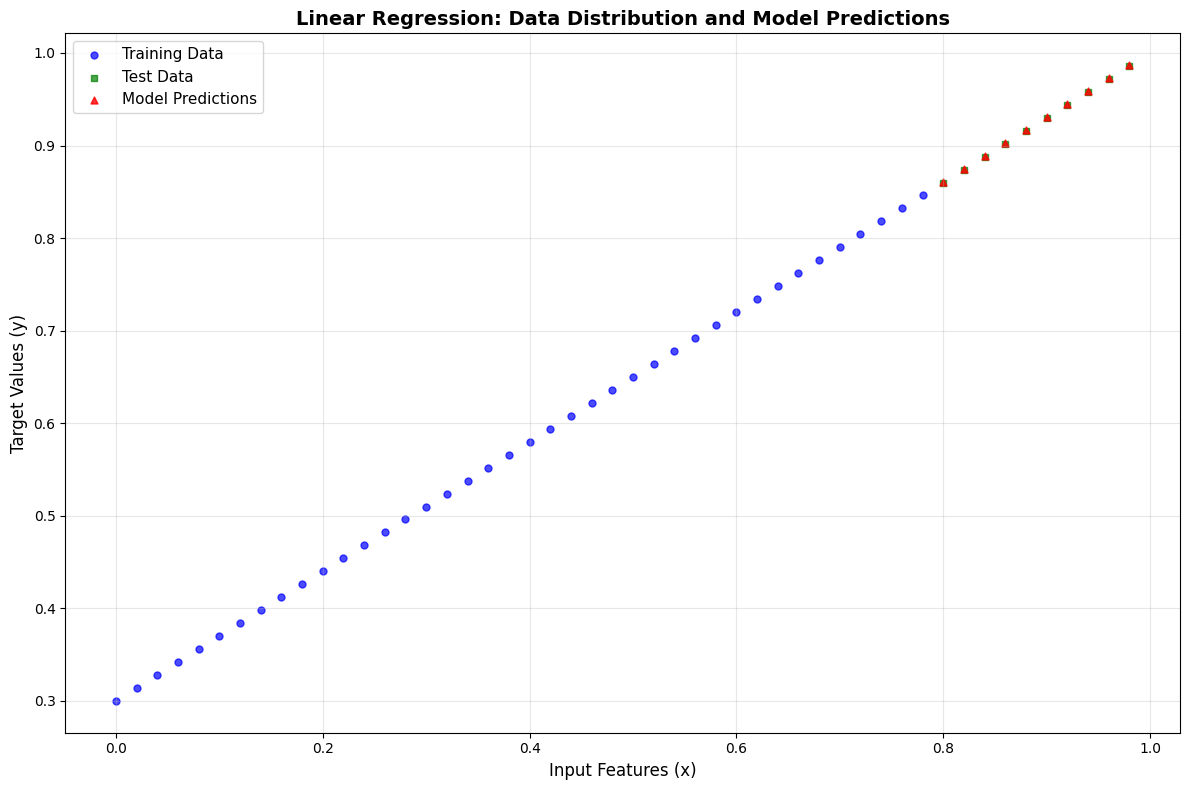

In [22]:
plot_predictions(predictions=y_preds)

## **6. Model Persistence and Reproducibility**

### **6.1 Theoretical Foundation of Model Serialization**

### **6.1 Model Serialization (Saving and Loading)**

**Why save the `state_dict`?**
The lecture emphasizes saving only the `state_dict` (the learned weights and biases) rather than the entire model object.

**The Risk**: Saving the whole model binds the data to the specific directory structure and class names. If you refactor your code or move files, your saved model will break. Saving the `state_dict` is the professional, flexible approach.

### **6.2 Saving a PyTorch model's `state_dict()`**

The [recommended way](https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-loading-model-for-inference) for saving and loading a model for inference (making predictions) is by saving and loading a model's `state_dict()`.

Let's see how we can do that in a few steps:

1. We'll create a directory for saving models to called `models` using Python's `pathlib` module.
2. We'll create a file path to save the model to.
3. We'll call `torch.save(obj, f)` where `obj` is the target model's `state_dict()` and `f` is the filename of where to save the model.

> **Note:** It's common convention for PyTorch saved models or objects to end with `.pt` or `.pth`, like `saved_model_01.pth`.


In [23]:
# Import pathlib for cross-platform file system operations
from pathlib import Path

# Step 1: Create directory structure for model artifacts
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
print(f"Model directory created: {MODEL_PATH.absolute()}")

# Step 2: Define model persistence parameters
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Include metadata in filename for better organization
# Format: [module]_[architecture]_[version]_[date].pth

# Step 3: Serialize model state dictionary
# This approach saves only the learned parameters, not the entire model architecture
print(f"Saving model state dictionary to: {MODEL_SAVE_PATH}")

# Save only the state_dict() containing learned parameters
torch.save(
    obj=model_0.state_dict(),  # Parameter dictionary (weights and biases)
    f=MODEL_SAVE_PATH          # Target file path
)

# Verify successful serialization
if MODEL_SAVE_PATH.exists():
    file_size = MODEL_SAVE_PATH.stat().st_size
    print(f"✓ Model saved successfully")
    print(f"  File size: {file_size} bytes")
    print(f"  Parameters saved: {len(model_0.state_dict())} tensors")
else:
    print("✗ Model saving failed")

# Display saved parameters for verification
print(f"\nSaved Model Parameters:")
saved_state = torch.load(MODEL_SAVE_PATH, weights_only=True)
for param_name, param_value in saved_state.items():
    print(f"  {param_name}: {param_value.item():.6f}")

Model directory created: /content/models
Saving model state dictionary to: models/01_pytorch_workflow_model_0.pth
✓ Model saved successfully
  File size: 2117 bytes
  Parameters saved: 2 tensors

Saved Model Parameters:
  weights: 0.700031
  bias: 0.300808


In [24]:
# Check the saved file path
!ls -l models/01_pytorch_workflow_model_0.pth

-rw-r--r-- 1 root root 2117 Jul 17 20:27 models/01_pytorch_workflow_model_0.pth


### **6.3 Loading a saved PyTorch model's `state_dict()`**

Since we've now got a saved model `state_dict()` at `models/01_pytorch_workflow_model_0.pth` we can now load it in using `torch.nn.Module.load_state_dict(torch.load(f))` where `f` is the filepath of our saved model `state_dict()`.

Why call `torch.load()` inside `torch.nn.Module.load_state_dict()`?

Because we only saved the model's `state_dict()` which is a dictionary of learned parameters and not the *entire* model, we first have to load the `state_dict()` with `torch.load()` and then pass that `state_dict()` to a new instance of our model (which is a subclass of `nn.Module`).

**Why not save the entire model?**

> The disadvantage of this approach *(saving the whole model)* is that the serialized data is bound to the specific classes and the exact directory structure used when the model is saved...
>
> Because of this, your code can break in various ways when used in other projects or after refactors.

In [25]:
# Demonstrate model restoration from saved state dictionary

# Step 1: Instantiate new model with random initialization
# This simulates loading a model in a new session or environment
loaded_model_0 = LinearRegressionModel()

print("Model Loading Process:")
print("=" * 40)

# Display initial random parameters
print("Initial Random Parameters:")
initial_state = loaded_model_0.state_dict()
for param_name, param_value in initial_state.items():
    print(f"  {param_name}: {param_value.item():.6f}")

# Step 2: Load saved state dictionary into model
# The weights_only=True parameter enhances security by preventing code execution
loaded_state_dict = torch.load(f=MODEL_SAVE_PATH, weights_only=True)
loaded_model_0.load_state_dict(loaded_state_dict)

print("\nParameters After Loading:")
restored_state = loaded_model_0.state_dict()
for param_name, param_value in restored_state.items():
    print(f"  {param_name}: {param_value.item():.6f}")

# Step 3: Verify parameter restoration accuracy
print("\nParameter Restoration Verification:")
original_state = model_0.state_dict()
restoration_success = True

for param_name in original_state.keys():
    original_val = original_state[param_name].item()
    restored_val = restored_state[param_name].item()
    difference = abs(original_val - restored_val)

    print(f"  {param_name}:")
    print(f"    Original: {original_val:.8f}")
    print(f"    Restored: {restored_val:.8f}")
    print(f"    Difference: {difference:.2e}")

    if difference > 1e-6:  # Tolerance for floating-point precision
        restoration_success = False

if restoration_success:
    print("\n✓ Perfect parameter restoration achieved!")
else:
    print("\n⚠ Parameter restoration discrepancies detected")

Model Loading Process:
Initial Random Parameters:
  weights: -0.599253
  bias: 0.501907

Parameters After Loading:
  weights: 0.700031
  bias: 0.300808

Parameter Restoration Verification:
  weights:
    Original: 0.70003080
    Restored: 0.70003080
    Difference: 0.00e+00
  bias:
    Original: 0.30080846
    Restored: 0.30080846
    Difference: 0.00e+00

✓ Perfect parameter restoration achieved!


In [26]:
# 1. Put the loaded model into evaluation mode
loaded_model_0.eval()

# 2. Use the inference mode context manager to make predictions
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test) # perform a forward pass on the test data with the loaded model

In [27]:
# Validate loaded model through prediction comparison

# Generate predictions using loaded model with proper evaluation protocol
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

# Compare predictions between original and loaded models
prediction_comparison = torch.allclose(y_preds, loaded_model_preds, atol=1e-6)

print("Model Validation Results:")
print("=" * 35)
print(f"Prediction Comparison: {'✓ PASS' if prediction_comparison else '✗ FAIL'}")

# Detailed comparison statistics
pred_differences = torch.abs(y_preds - loaded_model_preds)
max_difference = torch.max(pred_differences).item()
mean_difference = torch.mean(pred_differences).item()

print(f"Maximum Prediction Difference: {max_difference:.2e}")
print(f"Mean Prediction Difference: {mean_difference:.2e}")

# Evaluate loaded model performance
with torch.inference_mode():
    loaded_test_loss = loss_fn(loaded_model_preds, y_test)
    original_test_loss = loss_fn(y_preds, y_test)

print(f"\nPerformance Comparison:")
print(f"Original Model Loss: {original_test_loss:.8f}")
print(f"Loaded Model Loss: {loaded_test_loss:.8f}")
print(f"Loss Difference: {abs(original_test_loss - loaded_test_loss):.2e}")

if prediction_comparison and abs(original_test_loss - loaded_test_loss) < 1e-6:
    print("\n✓ Model loading and restoration verified successfully!")
    print("  The loaded model maintains identical performance to the original.")
else:
    print("\n⚠ Model restoration validation failed!")
    print("  Manual investigation required.")

Model Validation Results:
Prediction Comparison: ✓ PASS
Maximum Prediction Difference: 0.00e+00
Mean Prediction Difference: 0.00e+00

Performance Comparison:
Original Model Loss: 0.00083589
Loaded Model Loss: 0.00083589
Loss Difference: 0.00e+00

✓ Model loading and restoration verified successfully!
  The loaded model maintains identical performance to the original.


## **7. Complete Workflow Integration: Advanced Implementation**

### **7.1 Production-Ready Implementation**

**This section demonstrates the complete PyTorch workflow using advanced techniques suitable for production environments.** The implementation incorporates:

1. **Device-agnostic code** for CPU/GPU compatibility
2. **Enhanced model architecture** using PyTorch's built-in layers
3. **Comprehensive training protocols** with proper monitoring
4. **Professional model management** practices

#### **7.1.1 Learning Outcomes**

Upon completion of this section, students will understand:
- GPU acceleration and device management strategies
- Advanced PyTorch layer implementations (`nn.Linear`)
- Scalable training loop architectures
- Professional model versioning and deployment practices

> **Note**: For Google Colab users, GPU acceleration can be enabled via Runtime → Change runtime type → Hardware accelerator → GPU. Note that this will restart the runtime environment.

In [28]:
# Import PyTorch and matplotlib
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.11.0+cpu'

In [29]:
# Configure device-agnostic computation for optimal performance
# This enables automatic GPU utilization when available, with CPU fallback

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Computational Device Configuration:")
print(f"Selected Device: {device}")

if torch.cuda.is_available():
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("GPU not available - using CPU for computation")
    print("Note: GPU acceleration significantly improves training speed for large models")

Computational Device Configuration:
Selected Device: cpu
GPU not available - using CPU for computation
Note: GPU acceleration significantly improves training speed for large models


In [30]:
# Create weight and bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1) # without unsqueeze, errors will happen later on (shapes within linear layers)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [31]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

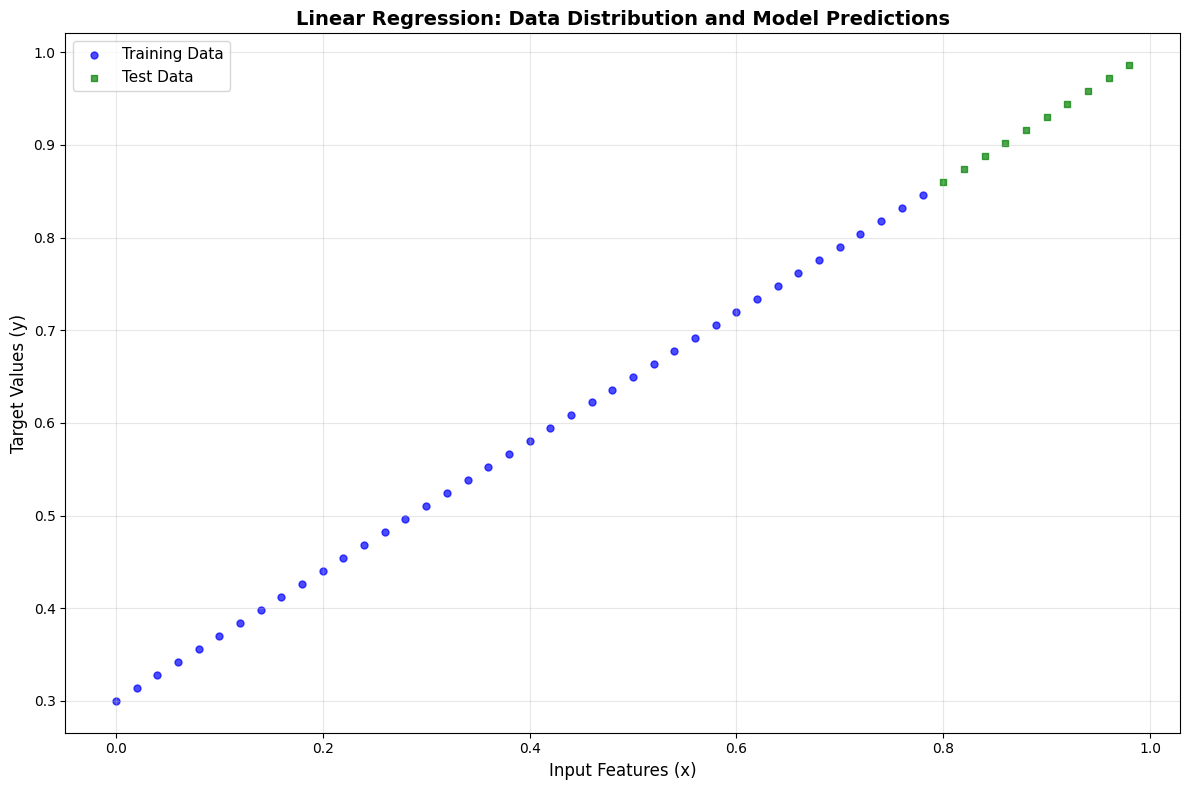

In [ ]:
# Note: If you've reset your runtime, this function won't work,
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train.detach().cpu(), y_train.detach().cpu(), X_test.detach().cpu(), y_test.detach().cpu())

In [32]:
# Advanced Linear Regression Model using PyTorch's optimized layers
class LinearRegressionModelV2(nn.Module):
    """
    Enhanced Linear Regression Model using PyTorch's optimized nn.Linear layer.

    This implementation leverages PyTorch's built-in linear transformation layer,
    which provides:
    - Optimized matrix operations for improved computational efficiency
    - Automatic parameter initialization using industry-standard methods
    - Built-in support for bias terms and various initialization strategies
    - Seamless integration with advanced optimization algorithms

    Architecture Specifications:
    - Input Features: 1 (univariate regression)
    - Output Features: 1 (single continuous prediction)
    - Parameters: 2 (weight matrix W ∈ ℝ¹ˣ¹, bias vector b ∈ ℝ¹)
    - Computational Complexity: O(1) per forward pass
    """

    def __init__(self):
        """
        Initialize model architecture with optimized linear layer.

        The nn.Linear layer implements the transformation y = xW^T + b
        where W is automatically initialized using Kaiming uniform distribution
        and b is initialized to zero by default.
        """
        super().__init__()

        # Implement linear transformation using PyTorch's optimized layer
        self.linear_layer = nn.Linear(
            in_features=1,   # Input dimensionality (single feature)
            out_features=1   # Output dimensionality (single prediction)
        )

        # Optional: Custom parameter initialization
        # nn.init.normal_(self.linear_layer.weight, mean=0.0, std=0.1)
        # nn.init.zeros_(self.linear_layer.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Execute forward pass through linear transformation.

        Parameters:
        -----------
        x : torch.Tensor
            Input tensor with shape [batch_size, in_features]

        Returns:
        --------
        torch.Tensor
            Output predictions with shape [batch_size, out_features]
        """
        # Apply linear transformation: y = xW^T + b
        return self.linear_layer(x)

# Initialize enhanced model with reproducible random seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()

print("Enhanced Model Architecture:")
print("=" * 40)
print(f"Model: {model_1}")
print(f"\nModel Parameters:")
for name, param in model_1.named_parameters():
    print(f"  {name}: {param.shape} | Values: {param.data.flatten()}")

print(f"\nTotal Parameters: {sum(p.numel() for p in model_1.parameters())}")
print(f"Trainable Parameters: {sum(p.numel() for p in model_1.parameters() if p.requires_grad)}")

Enhanced Model Architecture:
Model: LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

Model Parameters:
  linear_layer.weight: torch.Size([1, 1]) | Values: tensor([0.7645])
  linear_layer.bias: torch.Size([1]) | Values: tensor([0.8300])

Total Parameters: 2
Trainable Parameters: 2


In [33]:
# Check model device
next(model_1.parameters()).device

device(type='cpu')

In [34]:
# Set model to GPU if it's available, otherwise it'll default to CPU
model_1.to(device) # the device variable was set above to be "cuda" if available or "cpu" if not
next(model_1.parameters()).device

device(type='cpu')

In [35]:
# Create loss function
loss_fn = nn.L1Loss()

# Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(), # optimize newly created model's parameters
                            lr=0.001)

In [36]:
# Configure reproducible training environment
torch.manual_seed(42)

# Training hyperparameters for production-ready implementation
EPOCHS = 500
LEARNING_RATE = 0.01
PRINT_INTERVAL = 50

print("Production Training Configuration:")
print("=" * 50)
print(f"Device: {device}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Model Architecture: {model_1.__class__.__name__}")

# Transfer model to optimal computational device
model_1.to(device)
print(f"Model transferred to: {next(model_1.parameters()).device}")

# Transfer data tensors to match model device
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

print(f"Data transferred to: {X_train.device}")

# Configure optimization components
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=LEARNING_RATE)

# Initialize performance tracking
train_losses = []
test_losses = []
best_test_loss = float('inf')
best_epoch = 0

print(f"\nTraining Progress:")
print("=" * 70)
print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Test Loss':>12} | {'Best Test':>12}")
print("-" * 70)

# Execute comprehensive training loop
for epoch in range(EPOCHS):

    ### TRAINING PHASE ###
    model_1.train()

    # Forward pass with current parameters
    y_pred = model_1(X_train)

    # Compute training loss
    train_loss = loss_fn(y_pred, y_train)

    # Optimize parameters via gradient descent
    optimizer.zero_grad()  # Clear accumulated gradients
    train_loss.backward()  # Compute gradients via backpropagation
    optimizer.step()       # Update parameters

    ### EVALUATION PHASE ###
    model_1.eval()

    with torch.inference_mode():
        # Generate test predictions
        test_pred = model_1(X_test)

        # Compute test loss for generalization assessment
        test_loss = loss_fn(test_pred, y_test)

        # Track best performing model
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_epoch = epoch

    # Record metrics for analysis
    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())

    # Display progress at specified intervals
    if epoch % PRINT_INTERVAL == 0:
        print(f"{epoch:6d} | {train_loss.item():12.8f} | {test_loss.item():12.8f} | {best_test_loss.item():12.8f}")

print("-" * 70)
print(f"Training completed successfully!")
print(f"Best Test Loss: {best_test_loss:.8f} (Epoch {best_epoch})")
print(f"Final Train Loss: {train_losses[-1]:.8f}")
print(f"Final Test Loss: {test_losses[-1]:.8f}")

# Assess convergence quality
improvement_ratio = (train_losses[0] - train_losses[-1]) / train_losses[0] * 100
print(f"Training Loss Improvement: {improvement_ratio:.2f}%")

Production Training Configuration:
Device: cpu
Epochs: 500
Learning Rate: 0.01
Batch Size: 8
Model Architecture: LinearRegressionModelV2
Model transferred to: cpu
Data transferred to: cpu

Training Progress:
 Epoch |   Train Loss |    Test Loss |    Best Test
----------------------------------------------------------------------
     0 |   0.55517799 |   0.57397622 |   0.57397622
    50 |   0.02388639 |   0.04784907 |   0.00660699
   100 |   0.00621568 |   0.01408671 |   0.00660699
   150 |   0.00126450 |   0.01380181 |   0.00033082
   200 |   0.00126450 |   0.01380181 |   0.00033082
   250 |   0.00126450 |   0.01380181 |   0.00033082
   300 |   0.00126450 |   0.01380181 |   0.00033082
   350 |   0.00126450 |   0.01380181 |   0.00033082
   400 |   0.00126450 |   0.01380181 |   0.00033082
   450 |   0.00126450 |   0.01380181 |   0.00033082
----------------------------------------------------------------------
Training completed successfully!
Best Test Loss: 0.00033082 (Epoch 115)
Final 

In [37]:
# Find our model's learned parameters
from pprint import pprint # pprint = pretty print, see: https://docs.python.org/3/library/pprint.html
print("The model learned the following values for weights and bias:")
pprint(model_1.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


In [38]:
# Turn model into evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

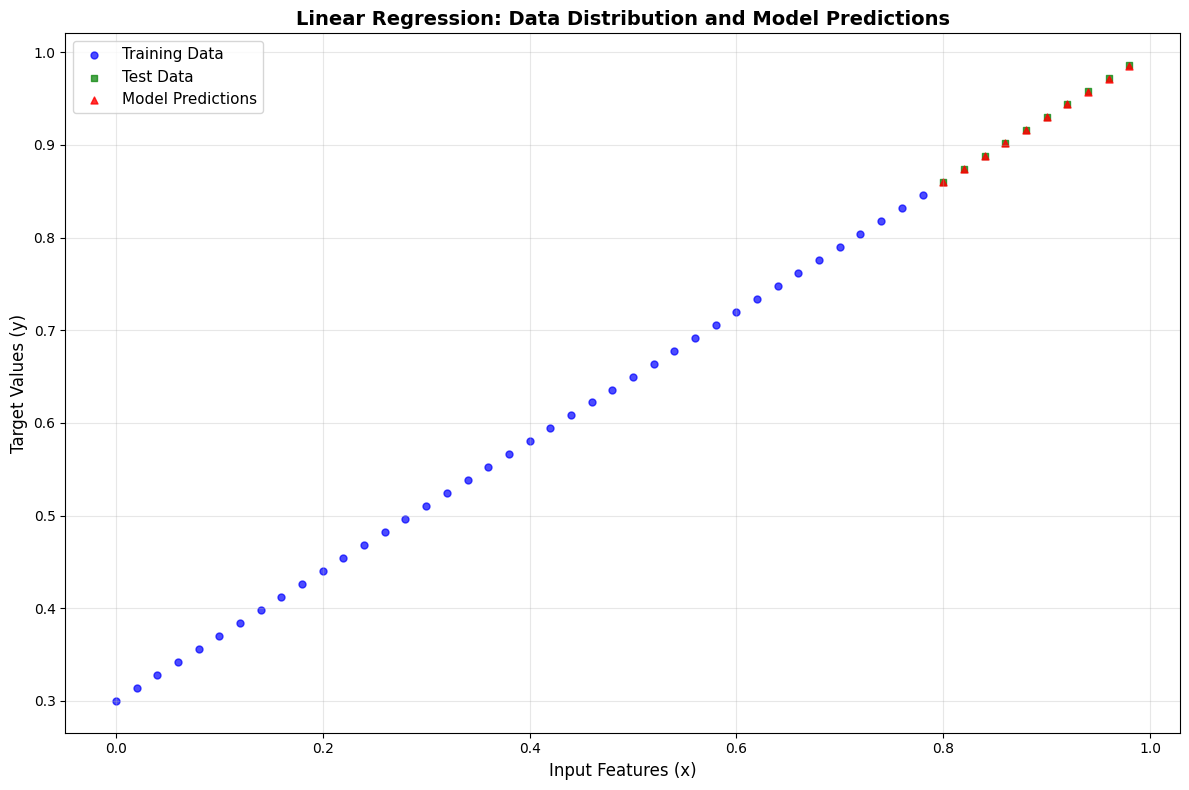

In [39]:
# plot_predictions(predictions=y_preds) # -> won't work... data not on CPU

# Put data on the CPU and plot it
plot_predictions(predictions=y_preds.cpu())

In [ ]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_1.pth


In [41]:
# Instantiate a fresh instance of LinearRegressionModelV2
loaded_model_1 = LinearRegressionModelV2()

# Load model state dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH, weights_only=True))

# Put model to target device (if your data is on GPU, model will have to be on GPU to make predictions)
loaded_model_1.to(device)

print(f"Loaded model:\n{loaded_model_1}")
print(f"Model on device:\n{next(loaded_model_1.parameters()).device}")

RuntimeError: Error(s) in loading state_dict for LinearRegressionModelV2:
	Missing key(s) in state_dict: "linear_layer.weight", "linear_layer.bias". 
	Unexpected key(s) in state_dict: "weights", "bias". 

In [42]:
# Evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False]])